In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path.cwd().parent
PARQUET_PATH = BASE_DIR / r"_2_feature_engineering+momentum\start\valid_bookings_for_marketing.parquet"
OUT_DIR = Path.cwd()

# Load the cleaned master bookings produced by new_eda.ipynb
master_bookings = pd.read_parquet(PARQUET_PATH)
marketing_activities = pd.read_csv("master_marketing_activties.csv")


In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

# -----------------------
# STEP 0A — Build bookings from master_bookings
# master_bookings already has: booking_date (datetime), is_outlier, outlier_reason
# from new_eda.ipynb. We alias columns to match the attribution pipeline.
# -----------------------
bookings = master_bookings.copy()

# Use the cleaned booking_date column; fall back to 'date' if somehow missing
if "booking_date" in bookings.columns:
    bookings["booking_datetime"] = pd.to_datetime(bookings["booking_date"], errors="coerce")
else:
    bookings["booking_datetime"] = pd.to_datetime(bookings["date"], errors="coerce")

# Alias revenue → revenue_thb for downstream cells
if "revenue_thb" not in bookings.columns and "revenue" in bookings.columns:
    bookings["revenue_thb"] = pd.to_numeric(bookings["revenue"], errors="coerce")

# Alias party_size → total_guests for downstream cells
if "total_guests" not in bookings.columns and "party_size" in bookings.columns:
    bookings["total_guests"] = bookings["party_size"]

bookings["restaurant_id"] = pd.to_numeric(bookings["restaurant_id"], errors="coerce")
bookings = bookings.dropna(subset=["restaurant_id", "booking_datetime"]).copy()

# # Exclude flagged outliers from attribution analysis
# if "is_outlier" in bookings.columns:
#     n_outliers = bookings["is_outlier"].sum()
#     bookings = bookings.loc[~bookings["is_outlier"]].copy()
#     print(f"Excluded {n_outliers:,} outlier rows from master_bookings")

print(f"Bookings available for attribution: {len(bookings):,}")

# -----------------------
# STEP 0B — Normalize marketing activity times + restaurant_id
# -----------------------
mkt = marketing_activities.copy()

# Create ONE restaurant_id column (covers CRM/KOL + FB multi-ids)
mkt["restaurant_id"] = (
    pd.to_numeric(mkt.get("crm_restaurant_id"), errors="coerce")
    .combine_first(pd.to_numeric(mkt.get("kol_restaurant_id"), errors="coerce"))
    .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id"), errors="coerce"))
)

def date_format_pattern(val):
    if pd.isna(val):
        return "NaT/None"
    s = str(val).strip()
    return re.sub(r'\d', 'd', s)

# Before dropna, fill null end dates using campaign_duration_days
mkt["activity_start"] = pd.to_datetime(mkt["activity_start"], errors="coerce").dt.normalize()
mkt["activity_end"]   = pd.to_datetime(mkt["activity_end"],   errors="coerce").dt.normalize()

# Fallback 1: use campaign duration
mkt["activity_end"] = mkt["activity_end"].fillna(
    mkt["activity_start"] + pd.to_timedelta(
        pd.to_numeric(mkt.get("fb_campaign_duration_days"), errors="coerce"), unit="D"
    )
)

# Fallback 2: anything still null → cap at today
mkt["activity_end"] = mkt["activity_end"].fillna(pd.Timestamp.today().normalize())

# Drop rows missing required keys
mkt = mkt.dropna(subset=["activity_id", "restaurant_id", "activity_start", "activity_end"]).copy()

# Ensure start <= end
mkt = mkt.loc[mkt["activity_end"] >= mkt["activity_start"]].copy()

# Keep only columns needed for attribution
mkt_exposure = mkt[[
    "activity_id", "channel", "restaurant_id",
    "activity_start", "activity_end",
    "crm_campaign_name", "crm_topic", "crm_audience",
    "kol_platform", "kol_username", "kol_post_url",
    "fb_campaign", "fb_amount_spent_thb"
]].copy()

# -----------------------
# STEP 0C — Interval join: bookings <-> marketing exposure windows
# -----------------------
cand = bookings[["id", "restaurant_id", "booking_datetime", "revenue_thb", "total_guests"]].merge(
    mkt_exposure,
    on="restaurant_id",
    how="left",
    suffixes=("_booking", "_mkt")
)

# Keep only where booking falls inside [activity_start, activity_end]
attrib = cand[
    (cand["booking_datetime"] >= cand["activity_start"]) &
    (cand["booking_datetime"] <= cand["activity_end"])
].copy()

# -----------------------
# STEP 0D — Resolve overlaps (one booking → one activity, closest start wins)
# -----------------------
attrib["time_from_start_hours"] = (
    attrib["booking_datetime"] - attrib["activity_start"]
).dt.total_seconds() / 3600.0
attrib["abs_time_from_start_hours"] = attrib["time_from_start_hours"].abs()

attrib = attrib.sort_values(["id", "abs_time_from_start_hours"])
attrib_1 = attrib.drop_duplicates(subset=["id"], keep="first").copy()

# -----------------------
# OUTPUTS
# -----------------------
attrib_1.to_csv(OUT_DIR / "booking_attribution_one_touch.csv", index=False)
attrib.to_csv(OUT_DIR / "booking_attribution_all_touches.csv", index=False)

print("Bookings fed in:           ", bookings.shape)
print("Marketing exposures:       ", mkt_exposure.shape)
print("Attributed bookings (1-touch):", attrib_1.shape)

print("\nShare of bookings attributed:")
print(attrib_1["channel"].value_counts(dropna=False, normalize=True).head(10))

print("\nTop campaigns by attributed bookings:")
print(attrib_1.groupby(["channel", "activity_id"]).size().sort_values(ascending=False).head(10))


Bookings available for attribution: 301,006
Bookings fed in:            (301006, 51)
Marketing exposures:        (2167, 13)
Attributed bookings (1-touch): (13343, 19)

Share of bookings attributed:
channel
KOL    0.504984
CRM    0.479278
FB     0.015739
Name: proportion, dtype: float64

Top campaigns by attributed bookings:
channel  activity_id     
KOL      KOL_d986b967c061    163
         KOL_bc274bb83c91    159
         KOL_7b7b8ac5c14a    147
         KOL_f53950bcfddd    133
         KOL_fd382d3c0771    122
         KOL_e16b90ab7e88    117
         KOL_c3e722cad7d7    115
         KOL_bfe994327b69    112
         KOL_fe57680c2d38    112
         KOL_2a2db3e7128e    109
dtype: int64


In [3]:
attrib_1

,id,restaurant_id,booking_datetime,revenue_thb,total_guests,activity_id,channel,activity_start,activity_end,crm_campaign_name,crm_topic,crm_audience,kol_platform,kol_username,kol_post_url,fb_campaign,fb_amount_spent_thb,time_from_start_hours,abs_time_from_start_hours
630487,6750402,3659,2025-01-05,12792.0,3,CRM_1c6c7398b8dc,CRM,2025-01-05,2025-01-07,TH_BKK_ctnoti_netcore_group_N_N_active_2025010...,you-i-premium-suki-buffet-jan25,group,NaN,NaN,NaN,NaN,NaN,0.0,0.0
626634,6754167,4874,2025-01-04,44960.0,6,CRM_488b7e0249a5,CRM,2025-01-03,2025-01-05,TH_BKK_ctnoti_netcore_group_N_N_active_2025010...,nuatair-4pay3-jan25,group,NaN,NaN,NaN,NaN,NaN,24.0,24.0
623230,6754221,3862,2025-01-03,19900.0,2,KOL_2fb28521c7f7,KOL,2024-12-31,2025-01-05,NaN,NaN,NaN,Instagram,thatlumlukkaguy,NaN,NaN,NaN,72.0,72.0
772991,6754380,2506,2025-02-08,27900.0,2,CRM_0de4b7edaa8b,CRM,2025-02-08,2025-02-10,TH_BKK_ctnoti_netcore_single_N_N_active_202502...,saffron-contemporary-feb25,single,NaN,NaN,NaN,NaN,NaN,0.0,0.0
626666,6754963,280,2025-01-04,35000.0,1,CRM_044d68c9632e,CRM,2025-01-02,2025-01-04,TH_BKK_ctnoti_netcore_group_N_N_active_2025010...,weekly-new-week1-jan25,group,NaN,NaN,NaN,NaN,NaN,48.0,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150668,8884687,6017,2026-01-10,41700.0,3,CRM_04a8df1977f4,CRM,2026-01-08,2026-01-10,TH_BKK_ctnoti_netcore_single_N_N_active_202601...,the-emerald-coffee-shop-jan26,single,NaN,NaN,NaN,NaN,NaN,48.0,48.0
2150669,8884736,6017,2026-01-10,41700.0,3,CRM_04a8df1977f4,CRM,2026-01-08,2026-01-10,TH_BKK_ctnoti_netcore_single_N_N_active_202601...,the-emerald-coffee-shop-jan26,single,NaN,NaN,NaN,NaN,NaN,48.0,48.0
2156835,8885115,6016,2026-01-11,34000.0,3,CRM_b6da259f37ac,CRM,2026-01-09,2026-01-11,TH_BKK_ctnoti_netcore_single_N_N_active_202601...,yok-chinese-restaurant-jan26,single,NaN,NaN,NaN,NaN,NaN,48.0,48.0
2156839,8886566,6016,2026-01-11,34000.0,3,CRM_b6da259f37ac,CRM,2026-01-09,2026-01-11,TH_BKK_ctnoti_netcore_single_N_N_active_202601...,yok-chinese-restaurant-jan26,single,NaN,NaN,NaN,NaN,NaN,48.0,48.0


In [4]:
import pandas as pd
import numpy as np

# --- make sure bookings datetime is real datetime ---
bookings = bookings.copy()
bookings["booking_datetime"] = pd.to_datetime(bookings["booking_datetime"], errors="coerce")
bookings["restaurant_id"] = pd.to_numeric(bookings["restaurant_id"], errors="coerce")
bookings = bookings.dropna(subset=["booking_datetime", "restaurant_id"]).copy()

# --- make sure marketing activity times are real datetime ---
mkt_lift = mkt_exposure.copy()

# 2️⃣ Build baseline window (same duration immediately BEFORE activity_start)
mkt_lift["window_hours"] = (mkt_lift["activity_end"] - mkt_lift["activity_start"]).dt.total_seconds() / 3600.0

# guard: if any window_hours is 0/negative (shouldn't happen, but just in case)
mkt_lift = mkt_lift.loc[mkt_lift["window_hours"] > 0].copy()

mkt_lift["baseline_start"] = mkt_lift["activity_start"] - pd.to_timedelta(mkt_lift["window_hours"], unit="h")
mkt_lift["baseline_end"]   = mkt_lift["activity_start"]

cand_during = bookings[["id", "restaurant_id", "booking_datetime"]].merge(
    mkt_lift[["activity_id", "restaurant_id", "activity_start", "activity_end"]],
    on="restaurant_id",
    how="inner"  # inner: only keep restaurants that exist in both
)

during_counts = cand_during[
    (cand_during["booking_datetime"] >= cand_during["activity_start"]) &
    (cand_during["booking_datetime"] <= cand_during["activity_end"])
].groupby("activity_id").size().rename("bookings_during")

# 3️⃣ Merge bookings to baseline window (candidate pairs by restaurant)
cand_baseline = bookings[["id", "restaurant_id", "booking_datetime"]].merge(
    mkt_lift[["activity_id", "restaurant_id", "baseline_start", "baseline_end"]],
    on="restaurant_id",
    how="left"
)

baseline = cand_baseline[
    (cand_baseline["booking_datetime"] >= cand_baseline["baseline_start"]) &
    (cand_baseline["booking_datetime"] <  cand_baseline["baseline_end"])
].copy()
baseline_counts = baseline.groupby("activity_id").size().rename("bookings_baseline")

# 4️⃣ Combine → lift table
lift_table = pd.concat([during_counts, baseline_counts], axis=1).fillna(0)
lift_table["lift"] = lift_table["bookings_during"] - lift_table["bookings_baseline"]
lift_table = lift_table.reset_index()

print(lift_table.head())
print(lift_table[["bookings_during","bookings_baseline","lift"]].describe())

lift_table

        activity_id  bookings_during  bookings_baseline  lift
0  CRM_005dde7ddbe8              4.0                3.0   1.0
1  CRM_00e026f097bf              2.0                0.0   2.0
2  CRM_01166ffb3fba              2.0                2.0   0.0
3  CRM_018b7df785fe              3.0                2.0   1.0
4  CRM_01bf9cd4838a             14.0               24.0 -10.0
       bookings_during  bookings_baseline         lift
count      1206.000000        1206.000000  1206.000000
mean         12.942786           9.444444     3.498342
std          21.613448          16.807669    10.568233
min           0.000000           0.000000   -39.000000
25%           2.000000           1.000000    -1.000000
50%           5.000000           4.000000     1.000000
75%          14.000000          10.000000     5.000000
max         168.000000         143.000000    92.000000


,activity_id,bookings_during,bookings_baseline,lift
0,CRM_005dde7ddbe8,4.0,3.0,1.0
1,CRM_00e026f097bf,2.0,0.0,2.0
2,CRM_01166ffb3fba,2.0,2.0,0.0
3,CRM_018b7df785fe,3.0,2.0,1.0
4,CRM_01bf9cd4838a,14.0,24.0,-10.0
...,...,...,...,...
1201,KOL_edde50264675,0.0,4.0,-4.0
1202,KOL_f67da58291ad,0.0,1.0,-1.0
1203,KOL_f6e44ca9f2ca,0.0,2.0,-2.0
1204,KOL_f86484b4abd2,0.0,1.0,-1.0


In [5]:
# Keep 1 row per activity_id with key metadata
mkt_meta = mkt_lift[[
    "activity_id", "channel", "restaurant_id",
    "activity_start", "activity_end", "window_hours",
    "crm_campaign_name", "crm_topic", "crm_audience",
    "kol_platform", "kol_username", "kol_post_url",
    "fb_campaign", "fb_amount_spent_thb"
]].drop_duplicates("activity_id")

activity_perf = lift_table.merge(mkt_meta, on="activity_id", how="left")

# Add ROI-like metrics when possible (FB)
# Bookings per day — normalises lift across different campaign durations
# WHY: A 30-day FB campaign with lift=10 is worse than a 3-day CRM with lift=10.
# Dividing by window days makes channels comparable.
activity_perf["window_days"] = activity_perf["window_hours"] / 24.0
activity_perf["lift_per_day"] = activity_perf["lift"] / activity_perf["window_days"]

# Cost per incremental booking
activity_perf["fb_amount_spent_thb"] = pd.to_numeric(activity_perf["fb_amount_spent_thb"], errors="coerce")
activity_perf["cost_per_incremental_booking"] = np.where(
    (activity_perf["channel"] == "FB") & activity_perf["lift"].gt(0) & activity_perf["fb_amount_spent_thb"].gt(0),
    activity_perf["fb_amount_spent_thb"] / activity_perf["lift"],
    np.nan
)

activity_perf.to_csv(OUT_DIR / "activity_performance_lift.csv", index=False)
print(activity_perf.sort_values("lift", ascending=False).head(10))
activity_perf

           activity_id  bookings_during  bookings_baseline  lift channel  \
868   KOL_7b7b8ac5c14a            147.0               55.0  92.0     KOL   
1034  KOL_d986b967c061            163.0               87.0  76.0     KOL   
357   CRM_928e80c73eca             73.0                1.0  72.0     CRM   
749   KOL_31c5d7409d15            109.0               53.0  56.0     KOL   
389   CRM_9d1c2d297e9d            106.0               51.0  55.0     CRM   
915   KOL_928275c4f185             81.0               27.0  54.0     KOL   
917   KOL_93cd3a683e2a            116.0               64.0  52.0     KOL   
765   KOL_3dc3908f6348            116.0               64.0  52.0     KOL   
990   KOL_bfe994327b69            112.0               63.0  49.0     KOL   
297   CRM_7a4b26ff7dda             71.0               24.0  47.0     CRM   

      restaurant_id activity_start activity_end  window_hours  \
868          4089.0     2025-08-22   2025-08-27         120.0   
1034         1826.0     2025-08-1

,activity_id,bookings_during,bookings_baseline,lift,channel,restaurant_id,activity_start,activity_end,window_hours,crm_campaign_name,crm_topic,crm_audience,kol_platform,kol_username,kol_post_url,fb_campaign,fb_amount_spent_thb,window_days,lift_per_day,cost_per_incremental_booking
0,CRM_005dde7ddbe8,4.0,3.0,1.0,CRM,3316.0,2025-03-02,2025-03-04,48.0,TH_BKK_ctnoti_netcore_group_N_N_active_2025030...,nuatair-mar25,group,NaN,NaN,NaN,NaN,NaN,2.0,0.5,NaN
1,CRM_00e026f097bf,2.0,0.0,2.0,CRM,3122.0,2025-09-26,2025-09-28,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202509...,ssd-the-oasis-at-hotel-nikko-sep25,single,NaN,NaN,NaN,NaN,NaN,2.0,1.0,NaN
2,CRM_01166ffb3fba,2.0,2.0,0.0,CRM,5828.0,2025-06-24,2025-06-26,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202506...,11th-purple-laurel-jun25,single,NaN,NaN,NaN,NaN,NaN,2.0,0.0,NaN
3,CRM_018b7df785fe,3.0,2.0,1.0,CRM,2012.0,2025-07-17,2025-07-19,48.0,TH_BKK_ctnoti_netcore_group_N_N_active_2025071...,oishi-eaterium-jul25,group,NaN,NaN,NaN,NaN,NaN,2.0,0.5,NaN
4,CRM_01bf9cd4838a,14.0,24.0,-10.0,CRM,6133.0,2025-07-14,2025-07-16,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202507...,bangkok-wonderland-jul25,single,NaN,NaN,NaN,NaN,NaN,2.0,-5.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,KOL_edde50264675,0.0,4.0,-4.0,KOL,5547.0,2025-11-03,2025-11-08,120.0,NaN,NaN,NaN,Instagram,lucy.rezel,NaN,NaN,NaN,5.0,-0.8,NaN
1202,KOL_f67da58291ad,0.0,1.0,-1.0,KOL,6057.0,2025-10-09,2025-10-14,120.0,NaN,NaN,NaN,Tiktok,hungryhub_sg,https://tiktok.com/@hungryhub_sg,NaN,NaN,5.0,-0.2,NaN
1203,KOL_f6e44ca9f2ca,0.0,2.0,-2.0,KOL,4311.0,2025-07-01,2025-07-06,120.0,NaN,NaN,NaN,Instagram,vanishaoct,Instagram.com/vanishaoct,NaN,NaN,5.0,-0.4,NaN
1204,KOL_f86484b4abd2,0.0,1.0,-1.0,KOL,6137.0,2025-10-27,2025-11-01,120.0,NaN,NaN,NaN,Instagram,liveloveatwithjie,NaN,NaN,NaN,5.0,-0.2,NaN


In [6]:
channel_summary = (
    activity_perf
    .groupby("channel", as_index=False)
    .agg(
        activities=("activity_id", "nunique"),
        total_bookings_during=("bookings_during", "sum"),
        total_baseline=("bookings_baseline", "sum"),
        total_lift=("lift", "sum"),
        avg_lift=("lift", "mean"),
        median_lift=("lift", "median"),
    )
)

channel_summary["lift_rate_vs_baseline"] = np.where(
    channel_summary["total_baseline"] > 0,
    channel_summary["total_lift"] / channel_summary["total_baseline"],
    np.nan
)

channel_summary.to_csv(OUT_DIR / "channel_summary.csv", index=False)
print(channel_summary)


  channel  activities  total_bookings_during  total_baseline  total_lift  \
0     CRM         702                 6627.0          4062.0      2565.0   
1      FB          12                  223.0           241.0       -18.0   
2     KOL         492                 8759.0          7087.0      1672.0   

   avg_lift  median_lift  lift_rate_vs_baseline  
0  3.653846          1.0               0.631462  
1 -1.500000         -1.0              -0.074689  
2  3.398374          1.0               0.235925  


OVERALL avg before: 9.44
OVERALL avg after : 12.94
OVERALL lift      : 3.50  (37.0%)

CHANNEL summary (avg per activity):
  channel  avg_before  avg_after  n_activities  avg_lift   pct_lift
0     CRM    5.786325   9.440171           702  3.653846  63.146233
2     KOL   14.404472  17.802846           492  3.398374  23.592493
1      FB   20.083333  18.583333            12 -1.500000  -7.468880


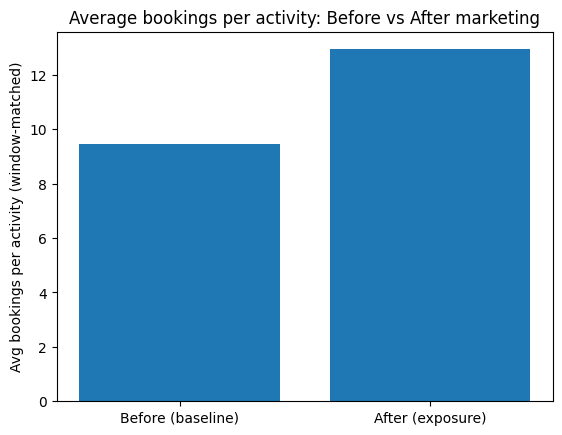

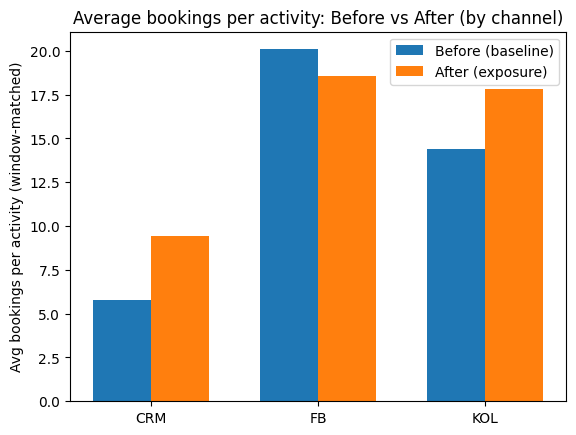

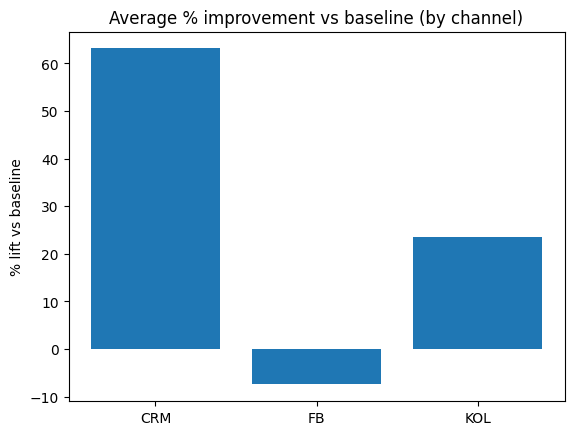

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Make sure you have these from your previous steps ---
# lift_table: columns = ["activity_id", "bookings_during", "bookings_baseline", "lift"]
# mkt: must contain ["activity_id", "channel"] and be 1 row per activity_id (or we'll dedupe)

mkt_meta = mkt[["activity_id", "channel"]].drop_duplicates("activity_id")
perf = lift_table.merge(mkt_meta, on="activity_id", how="left")

# --- 2) Overall averages ---
overall_before = perf["bookings_baseline"].mean()
overall_after  = perf["bookings_during"].mean()
overall_lift   = overall_after - overall_before
overall_pct    = np.nan if overall_before == 0 else (overall_lift / overall_before) * 100

print(f"OVERALL avg before: {overall_before:.2f}")
print(f"OVERALL avg after : {overall_after:.2f}")
print(f"OVERALL lift      : {overall_lift:.2f}  ({overall_pct:.1f}%)")

# --- 3) Channel averages (mean per activity) ---
channel_summary = (
    perf.groupby("channel", as_index=False)
        .agg(
            avg_before=("bookings_baseline", "mean"),
            avg_after=("bookings_during", "mean"),
            n_activities=("activity_id", "nunique"),
        )
)

channel_summary["avg_lift"] = channel_summary["avg_after"] - channel_summary["avg_before"]
channel_summary["pct_lift"] = np.where(
    channel_summary["avg_before"] > 0,
    (channel_summary["avg_lift"] / channel_summary["avg_before"]) * 100,
    np.nan
)

print("\nCHANNEL summary (avg per activity):")
print(channel_summary.sort_values("avg_lift", ascending=False))

# --- 4) Plot: Overall before vs after ---
plt.figure()
plt.bar(["Before (baseline)", "After (exposure)"], [overall_before, overall_after])
plt.title("Average bookings per activity: Before vs After marketing")
plt.ylabel("Avg bookings per activity (window-matched)")
plt.show()

# --- 5) Plot: By channel (grouped bars) ---
# (no seaborn; no specified colors)
channels = channel_summary["channel"].tolist()
x = np.arange(len(channels))
w = 0.35

plt.figure()
plt.bar(x - w/2, channel_summary["avg_before"], width=w, label="Before (baseline)")
plt.bar(x + w/2, channel_summary["avg_after"],  width=w, label="After (exposure)")
plt.xticks(x, channels)
plt.title("Average bookings per activity: Before vs After (by channel)")
plt.ylabel("Avg bookings per activity (window-matched)")
plt.legend()
plt.show()

# --- 6) Optional: Plot improvement (% lift) by channel ---
plt.figure()
plt.bar(channel_summary["channel"], channel_summary["pct_lift"])
plt.title("Average % improvement vs baseline (by channel)")
plt.ylabel("% lift vs baseline")
plt.show()


**Intuition is to relate the Overall Lift of the Marketing Campaign to the Overall Revenue generated by the Restaurant, and to calculate incremental revenue, to determine the ROI of each marketing campaign.**


In [8]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1️⃣ Calculate Total Revenue & AOV for each Campaign
# ---------------------------------------------------------
# Group your deduplicated bookings (attrib_1) to get the revenue driven during the campaign
revenue_data = attrib_1.groupby("activity_id").agg(
    total_campaign_revenue=("revenue_thb", "sum")
).reset_index()

# Merge this into your activity_perf table
activity_perf = activity_perf.merge(revenue_data, on="activity_id", how="left")

# Safely handle missing values (If a campaign got 0 bookings, revenue is 0)
activity_perf["total_campaign_revenue"] = activity_perf["total_campaign_revenue"].fillna(0)

# Calculate the Average Order Value (AOV) per booking for this campaign
activity_perf["aov_thb"] = np.where(
    activity_perf["bookings_during"] > 0,
    activity_perf["total_campaign_revenue"] / activity_perf["bookings_during"],
    0
)

# ---------------------------------------------------------
# 2️⃣ Calculate Financial Upside (Incremental Revenue)
# ---------------------------------------------------------
# Incremental Revenue = (Extra bookings generated) * (Average value of a booking)
# Using your original column name: "lift"
activity_perf["incremental_revenue_thb"] = activity_perf["lift"] * activity_perf["aov_thb"]

# ---------------------------------------------------------
# 3️⃣ Calculate Marketing ROI (Only for channels with spend, like FB)
# ---------------------------------------------------------
# Clean the spend column to be strictly numeric
activity_perf["fb_amount_spent_thb"] = pd.to_numeric(activity_perf["fb_amount_spent_thb"], errors="coerce").fillna(0)

# ROI Formula: (Return - Investment) / Investment
activity_perf["roi"] = np.where(
    (activity_perf["channel"] == "FB") & (activity_perf["fb_amount_spent_thb"] > 0),
    (activity_perf["incremental_revenue_thb"] - activity_perf["fb_amount_spent_thb"]) / activity_perf["fb_amount_spent_thb"],
    np.nan
)

# Format ROI as a percentage string for easier reading
activity_perf["roi_percentage"] = activity_perf["roi"] * 100

# ---------------------------------------------------------
# 4️⃣ View the Final Results
# ---------------------------------------------------------
print("--- Top Campaigns by True Financial ROI ---")

# Reverted to "lift" instead of "absolute_lift" to match your original input
roi_columns = [
    "activity_id", "channel", "lift", 
    "fb_amount_spent_thb", "incremental_revenue_thb", "roi_percentage"
]

# Sort by highest ROI
print(activity_perf.sort_values("roi", ascending=False)[roi_columns].head(10))

# Optional: Save the final enriched performance table
activity_perf.to_csv(OUT_DIR / "activity_performance_with_roi.csv", index=False)

--- Top Campaigns by True Financial ROI ---
          activity_id channel  lift  fb_amount_spent_thb  \
650   FB_b6f831a7763e      FB   4.0                 1.15   
649   FB_a6e93e593cb0      FB  26.0               295.84   
651   FB_d82ac819134f      FB   6.0                41.76   
645   FB_31effaf3224a      FB   5.0              3017.67   
654   FB_f16097867288      FB   0.0                 2.40   
1167  FB_fcd12b2a786b      FB  -1.0                 0.36   
646   FB_3c358ca900ba      FB  -4.0               146.85   
647   FB_64158c902a69      FB  -1.0                35.06   
655   FB_f7c640cf02a7      FB -16.0               115.17   
652   FB_db27a1a9c78f      FB  -5.0                22.78   

      incremental_revenue_thb  roi_percentage  
650              1.713562e+05    1.490044e+07  
649              1.172073e+06    3.960849e+05  
651              1.576152e+05    3.773310e+05  
645              2.522800e+05    8.260092e+03  
654              0.000000e+00   -1.000000e+02  
1167   

In [9]:
activity_perf

,activity_id,bookings_during,bookings_baseline,lift,channel,restaurant_id,activity_start,activity_end,window_hours,crm_campaign_name,...,fb_campaign,fb_amount_spent_thb,window_days,lift_per_day,cost_per_incremental_booking,total_campaign_revenue,aov_thb,incremental_revenue_thb,roi,roi_percentage
0,CRM_005dde7ddbe8,4.0,3.0,1.0,CRM,3316.0,2025-03-02,2025-03-04,48.0,TH_BKK_ctnoti_netcore_group_N_N_active_2025030...,...,NaN,0.0,2.0,0.5,NaN,88400.0,22100.000000,22100.000000,NaN,NaN
1,CRM_00e026f097bf,2.0,0.0,2.0,CRM,3122.0,2025-09-26,2025-09-28,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202509...,...,NaN,0.0,2.0,1.0,NaN,93950.0,46975.000000,93950.000000,NaN,NaN
2,CRM_01166ffb3fba,2.0,2.0,0.0,CRM,5828.0,2025-06-24,2025-06-26,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202506...,...,NaN,0.0,2.0,0.0,NaN,136488.0,68244.000000,0.000000,NaN,NaN
3,CRM_018b7df785fe,3.0,2.0,1.0,CRM,2012.0,2025-07-17,2025-07-19,48.0,TH_BKK_ctnoti_netcore_group_N_N_active_2025071...,...,NaN,0.0,2.0,0.5,NaN,52830.0,17610.000000,17610.000000,NaN,NaN
4,CRM_01bf9cd4838a,14.0,24.0,-10.0,CRM,6133.0,2025-07-14,2025-07-16,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202507...,...,NaN,0.0,2.0,-5.0,NaN,352500.0,25178.571429,-251785.714286,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,KOL_edde50264675,0.0,4.0,-4.0,KOL,5547.0,2025-11-03,2025-11-08,120.0,NaN,...,NaN,0.0,5.0,-0.8,NaN,0.0,0.000000,-0.000000,NaN,NaN
1202,KOL_f67da58291ad,0.0,1.0,-1.0,KOL,6057.0,2025-10-09,2025-10-14,120.0,NaN,...,NaN,0.0,5.0,-0.2,NaN,0.0,0.000000,-0.000000,NaN,NaN
1203,KOL_f6e44ca9f2ca,0.0,2.0,-2.0,KOL,4311.0,2025-07-01,2025-07-06,120.0,NaN,...,NaN,0.0,5.0,-0.4,NaN,0.0,0.000000,-0.000000,NaN,NaN
1204,KOL_f86484b4abd2,0.0,1.0,-1.0,KOL,6137.0,2025-10-27,2025-11-01,120.0,NaN,...,NaN,0.0,5.0,-0.2,NaN,0.0,0.000000,-0.000000,NaN,NaN


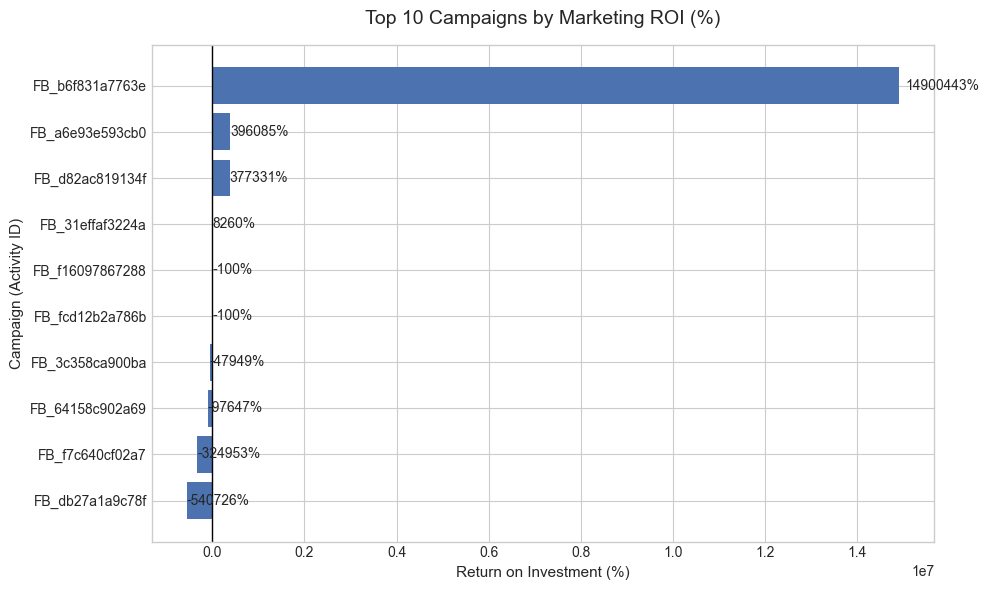

C:\Users\foogu\AppData\Local\Temp\ipykernel_26428\2984046605.py:54: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\foogu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


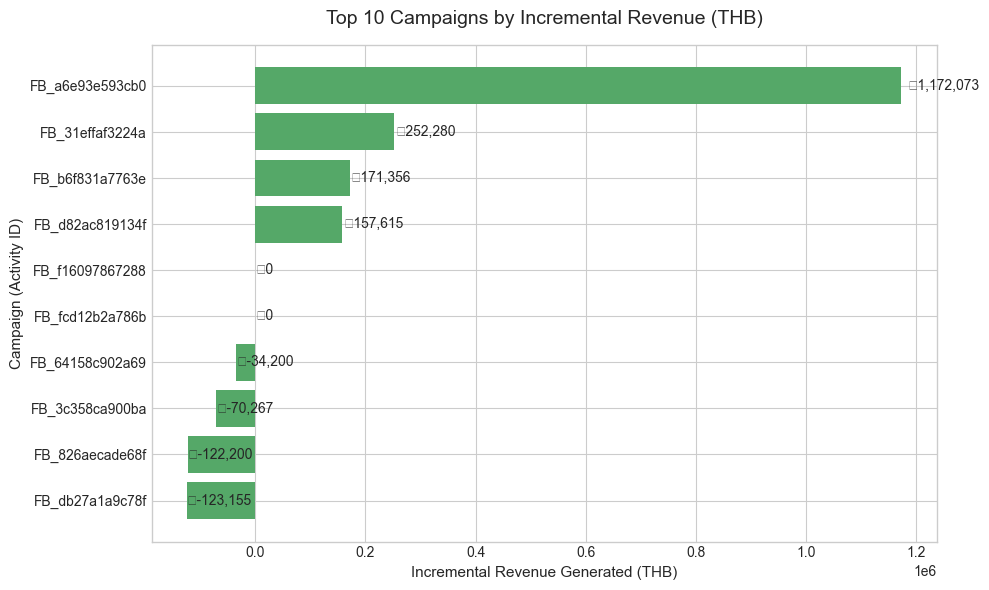

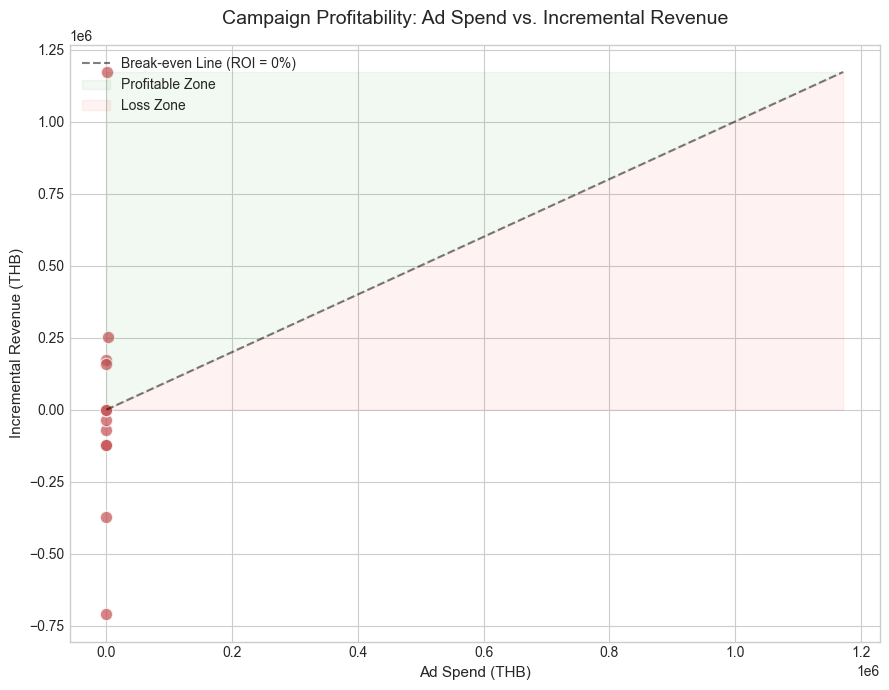

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- 0) Prepare the Data ---
# Filter out campaigns that didn't have any ad spend or valid ROI data
plot_data = activity_perf.dropna(subset=['roi']).copy()

# Sort by different metrics for different charts
top_roi = plot_data.sort_values('roi', ascending=False).head(10)
top_revenue = plot_data.sort_values('incremental_revenue_thb', ascending=False).head(10)

# Set a consistent style
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# CHART 1: Top 10 Campaigns by True Financial ROI
# ==========================================
plt.figure(figsize=(10, 6))
# Create horizontal bars (easiest to read campaign names)
bars1 = plt.barh(top_roi['activity_id'].astype(str), top_roi['roi_percentage'], color='#4C72B0')

plt.title('Top 10 Campaigns by Marketing ROI (%)', fontsize=14, pad=15)
plt.xlabel('Return on Investment (%)', fontsize=11)
plt.ylabel('Campaign (Activity ID)', fontsize=11)
plt.gca().invert_yaxis() # Highest ROI at the top

# Add the percentage labels to the bars
for bar in bars1:
    width = bar.get_width()
    plt.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2, 
             f'{width:.0f}%', va='center', fontsize=10)

plt.axvline(0, color='black', linewidth=1) # 0% Break-even line
plt.tight_layout()
plt.show()

# ==========================================
# CHART 2: Top 10 Campaigns by Total Upside (Incremental Revenue)
# ==========================================
plt.figure(figsize=(10, 6))
bars2 = plt.barh(top_revenue['activity_id'].astype(str), top_revenue['incremental_revenue_thb'], color='#55A868')

plt.title('Top 10 Campaigns by Incremental Revenue (THB)', fontsize=14, pad=15)
plt.xlabel('Incremental Revenue Generated (THB)', fontsize=11)
plt.ylabel('Campaign (Activity ID)', fontsize=11)
plt.gca().invert_yaxis()

# Add THB labels to the bars
for bar in bars2:
    width = bar.get_width()
    plt.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2, 
             f'฿{width:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================
# CHART 3: Ad Spend vs. Incremental Revenue (The "Profitability Matrix")
# ==========================================
plt.figure(figsize=(9, 7))

# Plot all campaigns (not just the top 10)
plt.scatter(plot_data['fb_amount_spent_thb'], plot_data['incremental_revenue_thb'], 
            alpha=0.7, color='#C44E52', s=80, edgecolor='white')

# Add the "Break-even" Line (Where Spend = Revenue)
max_val = max(plot_data['fb_amount_spent_thb'].max(), plot_data['incremental_revenue_thb'].max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', alpha=0.5, label='Break-even Line (ROI = 0%)')

plt.title('Campaign Profitability: Ad Spend vs. Incremental Revenue', fontsize=14, pad=15)
plt.xlabel('Ad Spend (THB)', fontsize=11)
plt.ylabel('Incremental Revenue (THB)', fontsize=11)

# Add shading to indicate Profit vs Loss zones
plt.fill_between([0, max_val], [0, max_val], max_val, color='green', alpha=0.05, label='Profitable Zone')
plt.fill_between([0, max_val], 0, [0, max_val], color='red', alpha=0.05, label='Loss Zone')

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Chart 1 (ROI Leaderboard): This shows efficiency. A campaign might not have generated the most money in total, but it gave you the best "bang for your buck." (Anything above the 0% line made a profit).

Chart 2 (Total Upside): This shows volume. This answers the question: "Which campaigns actually moved the needle the most for our total restaurant revenue?"

Chart 3 (Profitability Matrix / Scatter Plot): This is the most important chart for budget decisions.

Dots in the Green Zone (above the dashed line) made more money than they cost. You should increase budget for these types of campaigns.

Dots in the Red Zone (below the dashed line) cost more than they generated. You should stop or pause these campaigns immediately!